# Jupyter Notebook Explanation

## Overview
This notebook implements a repeated pipeline that processes given data through three main steps:

1. **Extracting Convolutional Layer Activations**
   - The final convolutional layer activations are obtained from AMFinder 252_tile for a given dataset.

2. **Computing UMAP Embeddings**
   - The extracted activations are transformed into lower-dimensional embeddings using UMAP

3. **Plotting the UMAP Visualization**
   - The UMAP embeddings are plotted to visualize the structure of the data in a lower-dimensional space



In [1]:
%matplotlib widget
import tensorflow as tf
import os
from tensorflow.keras.models import Model, load_model
import numpy as np           
import matplotlib.pyplot as plt
import matplotlib
import math
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from collections import Counter
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches


#from preprocessing import create_dataset, find_files_in_directory, process_dataset #this isnt needed ive created the files now

2025-01-31 08:43:50.410732: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738313030.425896    3081 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738313030.430344    3081 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-31 08:43:50.446391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
os.chdir('For Victor/amfinder-release-v2.1.2/amfinder/amf')
print(os.getcwd())
print(os.listdir())

/home/victor/Saliency Maps/For Victor/amfinder-release-v2.1.2/amfinder/amf
['colonized_activations.npy', 'all_activations.npy', 'amf', 'amfinder_predict.py', 'spatial_colonized_activations.npy', 'requirements_dev.txt', 'amfinder_config.py', 'requirements.txt', 'filter_visualization.py', 'embeddings_full_mis.npy', 'no_root_activations.npy', 'uncolonized_activations.npy', 'Correctly classified vs Misclassified data histogram plot.png', 'pure_purple_analysis.py', 'amfinder_model.py', 'amfinder_diagnose.py', 'Correct Data vs Misclassified Data for non-colonized roots.png', 'test_metrics.py', 'visualize_UMAP.py', 'trained_networks', 'amfinder_load.py', 'amfinder_tile_convert.py', '__pycache__', 'amfinder_test.py', 'amfinder_segmentation.py', 'install.sh', 'amfinder_image.py', 'metrics_collector.py', 'amfinder_altmodel.py', 'amfinder_calc.py', 'preprocessing.py', 'build', 'amfinder_plot.py', 'amfinder_train.py', 'split_data.py', 'amfinder_save.py', 'amfinder_superresolution.py', 'spatial_unc

In [3]:
from visualize_UMAP import test_save_activations_to_disk, umap_embeddings_from_disk, plot_clustered_umap, umap_plot

In [5]:
model = load_model('trained_networks/252_tile.h5')
layer_model = Model(inputs=model.input,
                    outputs=model.get_layer('C4').output)


In [6]:
#seperate mis and correctly classified within test 

#load data
x_spring_0 = np.load('Preprocessed_data/Data/Test/x_test_spring_0.npy')
x_spring_1 = np.load('Preprocessed_data/Data/Test/x_test_spring_1.npy')
x_summer_0 = np.load('Preprocessed_data/Data/Test/x_test_summer_0.npy')

#load true labels
x_spring_0_true = np.load('Preprocessed_data/Labels/True/y_test_spring_0.npy')
x_spring_0_true = np.argmax(x_spring_0_true, axis = 1)

x_spring_1_true =np.load('Preprocessed_data/Labels/True/y_test_spring_1.npy')
x_spring_1_true = np.argmax(x_spring_1_true, axis = 1)

x_summer_0_true = np.load('Preprocessed_data/Labels/True/y_test_summer_0.npy')
x_summer_0_true = np.argmax(x_summer_0_true, axis = 1)

#load predicted labels
x_spring_0_predicted = np.load('Preprocessed_data/Labels/Predicted/y_test_spring_0_predicted.npy')
x_spring_0_predicted = np.argmax(x_spring_0_predicted, axis = 1)

x_spring_1_predicted =np.load('Preprocessed_data/Labels/Predicted/y_test_spring_1_predicted.npy')
x_spring_1_predicted = np.argmax(x_spring_1_predicted, axis = 1)

x_summer_0_predicted = np.load('Preprocessed_data/Labels/Predicted/y_test_summer_0_predicted.npy')
x_summer_0_predicted = np.argmax(x_summer_0_predicted, axis = 1)

# 1.0 Clustered Test UMAP

In [6]:
random_seed = 80
test_save_activations_to_disk(
    data_list= [x_spring_0, x_spring_1, x_summer_0], 
    labels_list = [x_spring_0_true, x_spring_1_true, x_summer_0_true],
    layer_name = 'C4', 
    model = model,
    layer_model = layer_model,
    save_name = str(random_seed), 
    batch_size=100, 
    reduce_non_col=0.061, 
    reduce_no_root=0.115,
    random_seed = random_seed)


I0000 00:00:1738310263.688246   37052 service.cc:148] XLA service 0x7f43f4105010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738310263.688290   37052 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 SUPER, Compute Capability 7.5
2025-01-31 07:57:43.707412: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738310263.752487   37052 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-01-31 07:57:44.113013: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config"

KeyboardInterrupt: 

In [7]:
#define random seed incase activations already saved
random_seed = 80

In [8]:
# Load the indexes file
indexes_file = f'Preprocessed_data/activations/Test_activations/{str(random_seed)}_indices.npy'
indexes = np.load(indexes_file)
print(indexes.shape)
# True labels and predicted labels arrays
labels_list = [x_spring_0_true, x_spring_1_true, x_summer_0_true]

preds_list = [x_spring_0_predicted, x_spring_1_predicted, x_summer_0_predicted]

# Combine all true labels and predictions into single arrays
all_true_labels = np.concatenate(labels_list)
print(len(all_true_labels))
all_predicted_labels = np.concatenate(preds_list)
print(len(all_true_labels))

# Extract true labels and predicted labels using the indexes
true_labels = all_true_labels[indexes]
predicted_labels = all_predicted_labels[indexes]
print(true_labels.shape)

(632,)
5512
5512
(632,)


In [9]:
#save embeddings
reducing, embeddings = umap_embeddings_from_disk(activations_file_name = f'Preprocessed_data/activations/Test_activations/{str(random_seed)}_activations.npy', n_components=2, random_state=100)
embeddings.shape

/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


(632, 2)

In [ ]:
#load a specific activation
activations = np.load('Preprocessed_data/activations/Test_activations/1_activations.npy')
print(activations.shape)

(632, 160000)


In [ ]:
#verify lengths
uncolonized = [i for i, x in enumerate(true_labels) if x == 1]
colonized = [i for i, x in enumerate(true_labels) if x == 0]
no_root = [i for i, x in enumerate(true_labels) if x == 2]
print(len(colonized), len(uncolonized),  len(no_root))


211 211 210


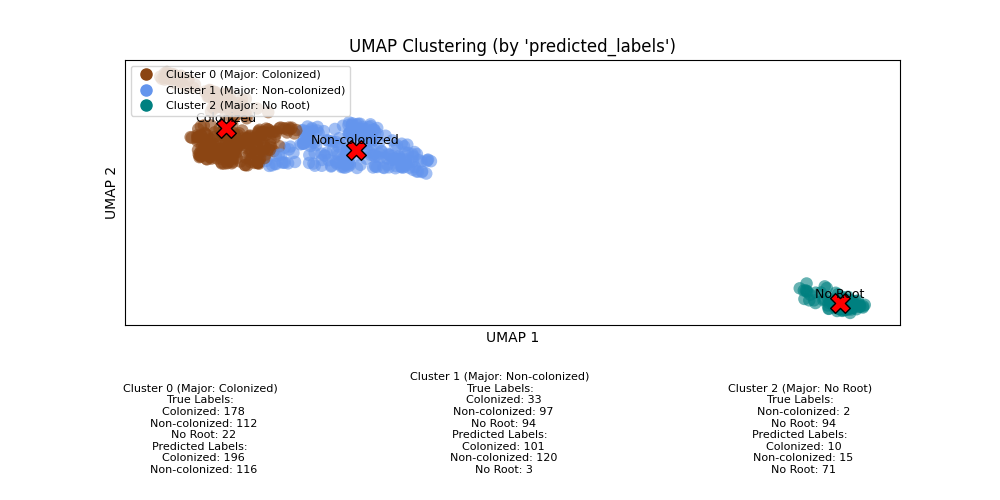

In [10]:
plot_clustered_umap(
    embeddings = embeddings, 
    true_labels = true_labels, 
    predicted_labels = predicted_labels, 
    class_names = ['Colonized', 'Non-colonized', 'No Root'], 
    images=None,
    cluster_by='predicted_labels',
    n_clusters=3
    )
plt.savefig(f'../../../../Figures/{str(random_seed)}_activations_UMAP.png', dpi=300, bbox_inches = 'tight')


# 2.0 Mis/Correct Classification Data

In [11]:
def split_data_by_classification(true_labels, predicted_labels, data_array):
    # Initialize lists for correct and misclassified indices
    cor_indexes = []
    mis_indexes = []

    # Find correct and misclassified indices
    for i, (true, pred) in enumerate(zip(true_labels, predicted_labels)):
        if true == pred:
            cor_indexes.append(i)  # Append correct index
        else:
            mis_indexes.append(i)  # Append incorrect index

    # Split the data array
    cor_data = data_array[cor_indexes]
    mis_data = data_array[mis_indexes]
    cor_label = true_labels[cor_indexes]
    mis_true_label = true_labels[mis_indexes]
    mis_pred_label = predicted_labels[mis_indexes]
    del data_array
    return cor_data, mis_data, cor_label, mis_true_label, mis_pred_label

In [12]:
cor_x_1, mis_x_1, cor_labels_1, mis_tlabel_1, mis_plabel_1 = split_data_by_classification(x_spring_0_true, x_spring_0_predicted, x_spring_0)
cor_x_2, mis_x_2, cor_labels_2, mis_tlabel_2, mis_plabel_2  = split_data_by_classification(x_spring_1_true, x_spring_1_predicted, x_spring_1)
cor_x_3, mis_x_3, cor_labels_3, mis_tlabel_3, mis_plabel_3  = split_data_by_classification(x_summer_0_true, x_summer_0_predicted, x_summer_0)

In [13]:
del x_spring_0, x_spring_1, x_summer_0, x_spring_0_true, x_spring_1_true, x_summer_0_true, x_spring_0_predicted, x_spring_1_predicted, x_summer_0_predicted

# 2.1 Correctly Classified

In [ ]:
random_seed = 100
test_save_activations_to_disk(
    data_list= [cor_x_1, cor_x_2, cor_x_3], 
    labels_list = [cor_labels_1, cor_labels_2, cor_labels_3],
    model= model, 
    layer_name = 'C4', 
    layer_model = layer_model,
    save_name = f'correct_{str(random_seed)}', 
    batch_size=100, 
    reduce_non_col=1, 
    reduce_no_root=1,
    random_seed = random_seed)

I0000 00:00:1738312897.152073    1598 service.cc:148] XLA service 0x7f849c004450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738312897.152396    1598 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 SUPER, Compute Capability 7.5
2025-01-31 08:41:37.167300: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738312897.211662    1598 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-01-31 08:41:37.560068: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config"

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

I0000 00:00:1738312900.086931    1598 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-01-31 08:41:40.924093: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,64,119,119]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,121,121]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 08:41:40.984000: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,128,57,57]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,59,59]{3,2,1,0

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 377ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


2025-01-31 08:41:42.509433: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[29,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[29,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 08:41:42.611337: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[29,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[29,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Activations saved to Preprocessed_data/activations/Test_activations/correct_30_activations.npy
Original reduced indices saved to Preprocessed_data/activations/Test_activations/correct_30_original_reduced_indices.npy


In [14]:
#define random_seed if activations are already made
#(random seed = 100 is the notation and random seed for full data (i.e. not reduced))
random_seed = 100

In [17]:
# Load the indexes file
indexes_file = f'Preprocessed_data/activations/Test_activations/correct_{str(random_seed)}_indices.npy'
indexes = np.load(indexes_file)

# True labels and predicted labels arrays
labels_list = [cor_labels_1, cor_labels_2, cor_labels_3]

# Combine all true labels and predictions into single arrays
all_true_labels = np.concatenate(labels_list)

# Extract true labels and predicted labels using the indexes
true_labels = all_true_labels[indexes]
print(true_labels.shape)
# activations = np.load(f'Preprocessed_data/activations/Test_activations/correct_{str(random_seed)}_activations.npy')
# print(activations.shape)

(2747,)


In [10]:
reducing, embeddings = umap_embeddings_from_disk(activations_file_name = f'Preprocessed_data/activations/Test_activations/correct_{str(random_seed)}_activations.npy', n_components=2, random_state=100)
embeddings.shape


/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


(429, 2)

In [ ]:
#load specific files
activations = np.load('Preprocessed_data/activations/Test_activations/1_correct_activations.npy')
indices = np.load('Preprocessed_data/activations/Test_activations/1_correct_indices.npy')

In [11]:
uncolonized = [i for i, x in enumerate(true_labels) if x == 1]
colonized = [i for i, x in enumerate(true_labels) if x == 0]
no_root = [i for i, x in enumerate(true_labels) if x == 2]
print(len(colonized), len(uncolonized),  len(no_root))

172 1984 591


In [15]:
#load embeddings if already saved
embeddings = np.load('embeddings_full_corr.npy')

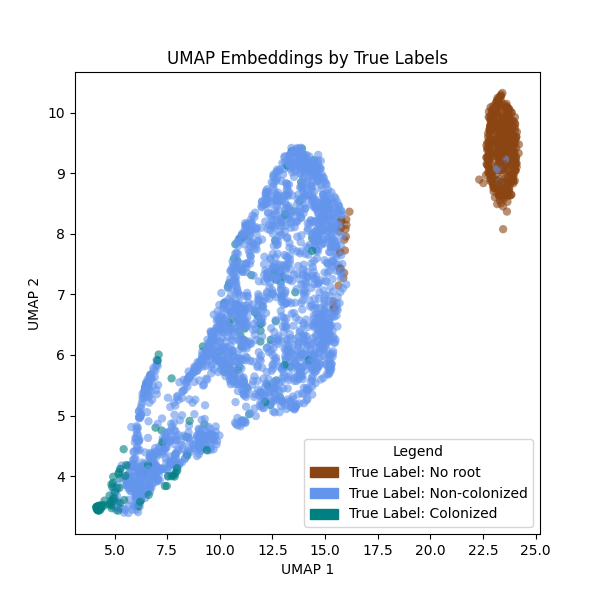

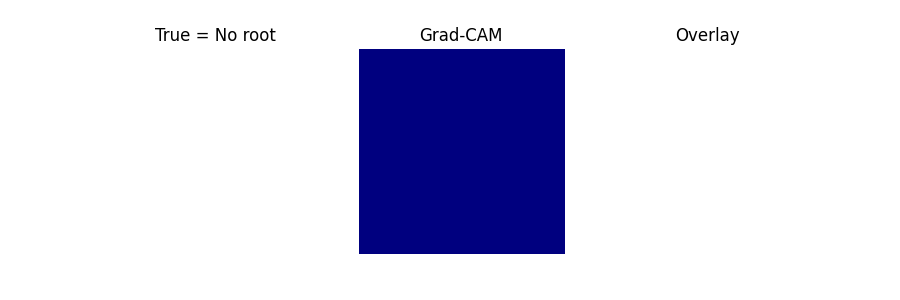

/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_1']
Received: inputs=Tensor(shape=(1, 252, 252, 3))
  warnings.warn(msg)
I0000 00:00:1738313139.065868    3081 cuda_dnn.cc:529] Loaded cuDNN version 90600


In [ ]:
fig, fig_image = umap_plot(embeddings, 
                 true_labels, 
                 model = model,
                 images = np.concatenate((cor_x_1, cor_x_2, cor_x_3), axis = 0), 
                 indices = indexes , 
                 index_labels = np.concatenate((cor_labels_1, cor_labels_2, cor_labels_3), axis = 0))

# Save the UMAP plot
#fig.savefig(f'../../../../Figures/Fig_2/{str(random_seed)}_UMAP_plot.png', dpi=300, bbox_inches='tight')




## 2.2 Misclassified

In [14]:
random_seed = 100
test_save_activations_to_disk(
    data_list= [mis_x_1, mis_x_2, mis_x_3], 
    labels_list = [mis_tlabel_1, mis_tlabel_2, mis_tlabel_3], 
    model= model, 
    layer_name = 'C4', 
    layer_model = layer_model,
    save_name = f'mis_{str(random_seed)}', 
    batch_size=100,
    reduce_non_col = 1,
    reduce_no_root = 1,
    random_seed = random_seed 
)

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step 

2025-01-18 15:12:16.749565: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,64,119,119]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,121,121]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-18 15:12:16.802926: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,128,57,57]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,59,59]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_co

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━

2025-01-18 15:12:25.814607: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,64,119,119]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,64,121,121]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-18 15:12:25.858150: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,128,57,57]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,64,59,59]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_co

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step
Activations saved to Preprocessed_data/activations/Test_activations/mis_100_activations.npy
Original reduced indices saved to Preprocessed_data/activations/Test_activations/mis_100_original_reduced_indices.npy


In [19]:
# Load the indexes file
indexes_file = f'Preprocessed_data/activations/Test_activations/mis_{str(random_seed)}_indices.npy'
indexes = np.load(indexes_file)

# True labels and predicted labels arrays
labels_list = [mis_tlabel_1, mis_tlabel_2, mis_tlabel_3]
preds_list = [mis_plabel_1, mis_plabel_2, mis_plabel_3]

# Combine all true labels and predictions into single arrays
all_true_labels = np.concatenate(labels_list)
all_predicted_labels = np.concatenate(preds_list)

# Extract true labels and predicted labels using the indexes
true_labels = all_true_labels[indexes]
predicted_labels = all_predicted_labels[indexes]

print(true_labels.shape)
activations = np.load(f'Preprocessed_data/activations/Test_activations/mis_{str(random_seed)}_activations.npy')
print(activations.shape)


(2765,)
(2765, 160000)


In [ ]:
reducing, embeddings = umap_embeddings_from_disk(activations_file_name = f'Preprocessed_data/activations/Test_activations/mis_{str(random_seed)}_activations.npy', n_components=2, random_state=100)
embeddings.shape

/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


(2765, 2)

In [ ]:
#np.save('embeddings_full_mis.npy', embeddings)

In [18]:
uncolonized = [i for i, x in enumerate(true_labels) if x == 1]
colonized = [i for i, x in enumerate(true_labels) if x == 0]
no_root = [i for i, x in enumerate(true_labels) if x == 2]
print(len(colonized), len(uncolonized),  len(no_root))

39 1487 1239


NameError: name 'x_spring_0' is not defined

In [20]:
embeddings = np.load('embeddings_full_mis.npy')

(<Figure size 600x600 with 1 Axes>, <Figure size 900x300 with 3 Axes>)

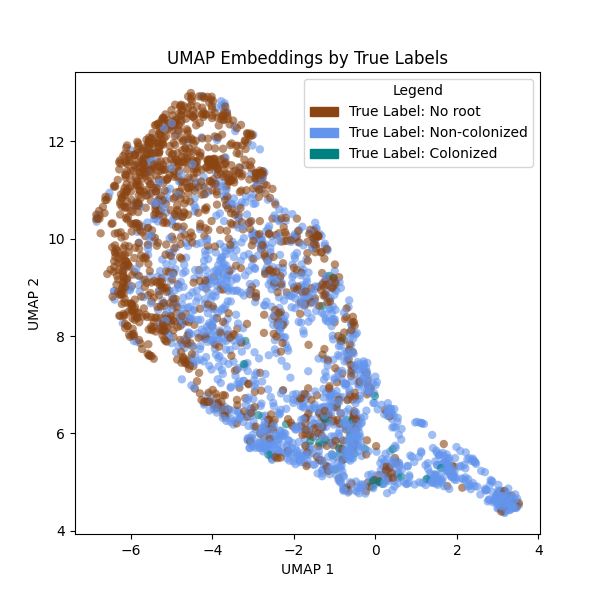

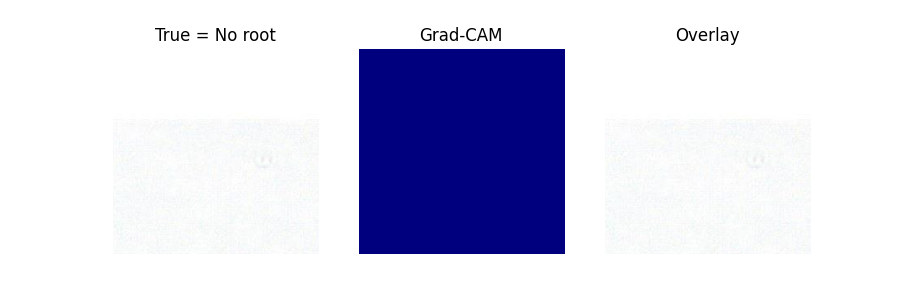

In [21]:
umap_plot(embeddings, 
                 true_labels, 
                 model = model,
                 predicted_labels = predicted_labels, 
                 indices = indexes, 
                 images = np.concatenate((mis_x_1, mis_x_2, mis_x_3), axis = 0), 
                 index_labels = np.concatenate((mis_tlabel_1, mis_tlabel_2, mis_tlabel_3), axis = 0), 
                 p_index_labels = np.concatenate((mis_plabel_1, mis_plabel_2, mis_plabel_3), axis = 0))
#fig.savefig(f'../../../../Figures/Fig_2/{str(random_seed)}_mis_UMAP_plot.png', dpi=300, bbox_inches='tight')